# Experiment Design & Statistical Analysis

## Google Merchandise Store — Product Analytics Project

### Business Question

Our analysis suggests that returning users are substantially more likely to purchase
than first-time users, while first-time user retention is relatively weak.

This notebook uses the observed data to:

1. Establish baseline product metrics
2. Define an experiment around first-session product discovery
3. Select and justify the primary metric
4. Translate a relative MDE into an absolute improvement
5. Calculate the required experiment sample size
6. Define the statistical hypotheses and decision framework

## 1. Baseline Findings

Our BigQuery analysis produced the following baseline metrics:

- Overall session purchase rate: 1.35%
- New-user session purchase rate: 0.68%
- Returning-user session purchase rate: 3.10%
- Returning sessions convert approximately 4.6× higher than new sessions
- Week-1 retention for major cohorts is generally only a few percent
- Product-view → add-to-cart is a major funnel drop-off in periods where cart-event coverage is available
- Device-level conversion is relatively similar across desktop, mobile, and tablet

### Initial Product Hypothesis

The main opportunity may be improving the transition from first-time visitor
to returning user, rather than solving a device-specific conversion problem.

### Funnel Baseline

The observed session funnel shows substantial drop-off between product discovery and purchase. Visualizing the funnel helps identify where an intervention could have the greatest potential impact.

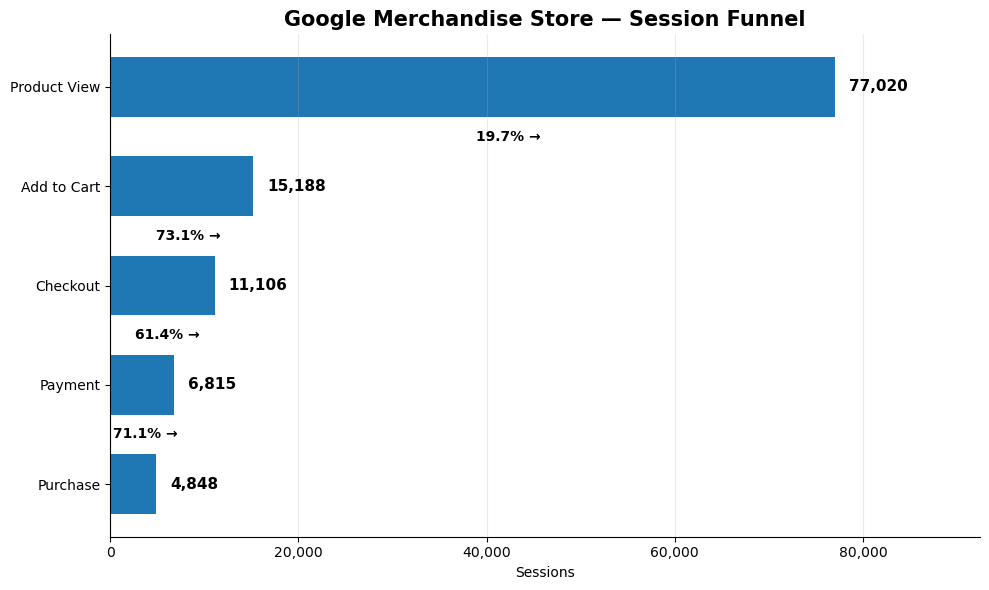

In [27]:
import matplotlib.pyplot as plt

# Observed session-level funnel counts
funnel_stages = [
    "Product View",
    "Add to Cart",
    "Checkout",
    "Payment",
    "Purchase"
]

funnel_counts = [
    77020,
    15188,
    11106,
    6815,
    4848
]

plt.figure(figsize=(10, 6))

bars = plt.barh(
    funnel_stages[::-1],
    funnel_counts[::-1],
    height=0.6
)

plt.xlabel("Sessions")

plt.title(
    "Google Merchandise Store — Session Funnel",
    fontsize=15,
    fontweight="bold"
)

# Add session count labels
for bar, value in zip(bars, funnel_counts[::-1]):
    plt.text(
        bar.get_width() + 1500,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,}",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

# Calculate stage-to-stage conversion
conversion_rates = [
    funnel_counts[1] / funnel_counts[0] * 100,
    funnel_counts[2] / funnel_counts[1] * 100,
    funnel_counts[3] / funnel_counts[2] * 100,
    funnel_counts[4] / funnel_counts[3] * 100
]

# Add conversion percentages
for i, rate in enumerate(conversion_rates):
    plt.text(
        funnel_counts[i] * 0.55,
        len(funnel_stages) - 1.5 - i,
        f"{rate:.1f}% →",
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.xlim(
    0,
    max(funnel_counts) * 1.20
)

# Format x-axis
plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x):,}")
)

# Clean up chart
plt.grid(
    axis="x",
    alpha=0.25
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [11]:
%pip install statsmodels

  Using cached patsy-1.0.3-py2.py3-none-any.whl.metadata (3.7 kB)
  Using cached formulaic-1.2.2-py3-none-any.whl.metadata (7.0 kB)
  Using cached interface_meta-2.0.1-py3-none-any.whl.metadata (6.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 12.8 MB/s  0:00:003.4 MB/s eta 0:00:01
Using cached formulaic-1.2.2-py3-none-any.whl (118 kB)
Using cached interface_meta-2.0.1-py3-none-any.whl (15 kB)
Using cached patsy-1.0.3-py2.py3-none-any.whl (233 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [statsmodels] 3/4 [statsmodels]

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: /Users/waheed/miniconda3/envs/ml-main/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [24]:
import pandas as pd
import numpy as np
import math

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

## 2. Define the Experiment

### Proposed Experiment

Target: New users

Control:
Existing first-session product discovery experience

Treatment:
Improved first-session product discovery experience

### Primary Metric

7-day retention

7-day retention =
users who return within 7 days / eligible new users

### Secondary Metrics

- View → Add-to-cart conversion
- Purchase conversion

### Guardrails

- Revenue per session
- Purchase rate
- Engagement

## 3. Baseline and MDE

For experiment planning we use:

Baseline 7-day retention = 5.5%

We target a 20% relative improvement.

Therefore:

Target retention = 5.5% × 1.20 = 6.6%

Absolute improvement:

6.6% - 5.5% = +1.1 percentage points

#### Important wording
- 5.5% is a planning baseline, not a claim that every cohort has exactly 5.5% retention.
Our actual cohorts vary, so we're choosing this as a reasonable planning assumption.

In [13]:
baseline = 0.055
relative_mde = 0.20

target = baseline * (1 + relative_mde)
absolute_effect = target - baseline

print(f"Baseline retention: {baseline:.1%}")
print(f"Relative MDE: {relative_mde:.0%}")
print(f"Target retention: {target:.1%}")
print(f"Absolute improvement: {absolute_effect:.1%}")
print(f"Absolute improvement in percentage points: {absolute_effect * 100:.1f} pp")

Baseline retention: 5.5%
Relative MDE: 20%
Target retention: 6.6%
Absolute improvement: 1.1%
Absolute improvement in percentage points: 1.1 pp


## 4. Statistical Hypotheses

### Null Hypothesis (H₀)

The treatment does not improve 7-day retention.

### Alternative Hypothesis (H₁)

The treatment improves 7-day retention.

### Experiment Parameters

- Significance level (α): 0.05
- Statistical power: 0.80
- Test: Two-sided comparison of proportions

In [17]:
alpha = 0.05
power = 0.80

effect_size = proportion_effectsize(
    baseline,
    target
)

sample_size = NormalIndPower().solve_power(
    effect_size=abs(effect_size),
    alpha=alpha,
    power=power,
    ratio=1,
    alternative="two-sided"
)

sample_size = math.ceil(sample_size)

print(f"Required sample size per group: {sample_size:,}")
print(f"Required total sample size: {sample_size * 2:,}")

Required sample size per group: 7,360
Required total sample size: 14,720


## 5. Sample Size Interpretation

### Planning assumptions

Baseline = 5.5%

Target = 6.6%

Relative MDE = 20%

Absolute MDE = +1.1 percentage points

α = 0.05

Power = 80%

### Result

Approximately 7,360 users are required per group,
or approximately 14,720 users in total.

This means the experiment should be designed with enough
eligible new users in both control and treatment to detect
the planned improvement with 80% power at a 5% significance level.

### New vs Returning Conversion

Returning sessions convert substantially better than new sessions. This lifecycle difference provides additional context for why improving the first-session experience may be important.

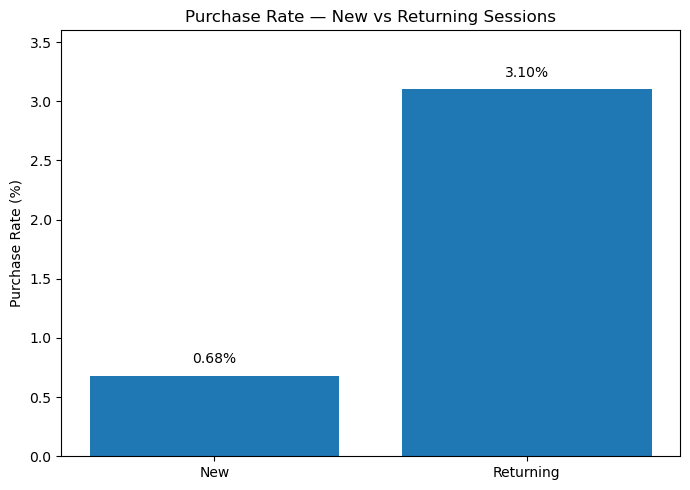

In [26]:

user_types = [
    "New",
    "Returning"
]

purchase_rates = [
    0.68,
    3.10
]

plt.figure(figsize=(7, 5))

bars = plt.bar(
    user_types,
    purchase_rates
)

plt.ylabel("Purchase Rate (%)")
plt.title("Purchase Rate — New vs Returning Sessions")

for bar, value in zip(bars, purchase_rates):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.08,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, 3.6)
plt.tight_layout()
plt.show()

## 6. Why Retention Is Primary

We use 7-day retention as the primary metric for two reasons:

### Product reason

The main observed lifecycle gap is between first-time and returning users.
Returning sessions have substantially higher purchase conversion than new sessions.

### Statistical reason

New-user purchase conversion is only 0.68%.
Using purchase as the primary metric would make small improvements difficult
to detect efficiently because the event is relatively rare.

Therefore:

Primary:
7-day retention

Secondary:
View → Add-to-cart conversion
Purchase conversion

This allows the experiment to measure the intended behavioral change
while still monitoring downstream business impact.

## 7. Experiment Decision Framework

We would consider the treatment successful if:

1. 7-day retention shows a statistically significant improvement
2. The observed effect meets or exceeds the business-relevant MDE
3. No important guardrail metric deteriorates materially

A statistically significant result alone is not sufficient.
The observed effect should also be practically meaningful.

## 8. Example A/B Test Result

The historical GA4 dataset is observational, so it does not contain a real randomized
experiment.

To demonstrate how the experiment would be evaluated after launch, we simulate a
plausible post-experiment result using the same planning framework.

Assume:

- Control: 7,360 users
- Treatment: 7,360 users
- Control retention: 5.5%
- Treatment retention: 7.0%

We will compare the two proportions using a one-sided two-proportion test and
estimate the confidence interval for the treatment-control difference.

This is a simulated example for methodology demonstration, not an observed
result from the Google Merchandise Store.

In [20]:
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import confint_proportions_2indep

control_n = 7360
treatment_n = 7360

control_retained = 405
treatment_retained = 515

control_rate = control_retained / control_n
treatment_rate = treatment_retained / treatment_n

absolute_lift = treatment_rate - control_rate
relative_lift = absolute_lift / control_rate

z_stat, p_value = proportions_ztest(
    [treatment_retained, control_retained],
    [treatment_n, control_n],
    alternative = "larger"
)

ci_low, ci_high = confint_proportions_2indep(
    treatment_retained,
    treatment_n,
    control_retained,
    control_n,
    method = "score",
    compare = "diff",
    alpha = 0.05
)

print(f"Control retention:   {control_rate:.2%}")
print(f"Treatment retention: {treatment_rate:.2%}")
print(f"Absolute lift:       {absolute_lift:.2%}")
print(f"Relative lift:       {relative_lift:.1%}")
print(f"Z-statistic:         {z_stat:.3f}")
print(f"P-value:             {p_value:.5f}")
print(f"95% CI for lift:     [{ci_low:.2%}, {ci_high:.2%}]")

Control retention:   5.50%
Treatment retention: 7.00%
Absolute lift:       1.49%
Relative lift:       27.2%
Z-statistic:         3.746
P-value:             0.00009
95% CI for lift:     [0.71%, 2.28%]


## Interpretation

In this simulated example:

- Treatment retention is 7.0% versus 5.5% in control.
- The absolute improvement is 1.5 percentage points.
- The relative improvement is approximately 27%.
- The p-value is below 0.05, so we reject the null hypothesis in favor of an improvement.
- The 95% confidence interval for the treatment-control difference is entirely above zero.

The result would therefore provide evidence that the treatment improved 7-day retention.

However, statistical significance is not enough on its own. We would also check the
predefined guardrail metrics and confirm that the observed improvement is commercially
meaningful.

In [23]:
df = pd.read_csv("bq-results-20261005-135306-1791208412179.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360129 entries, 0 to 360128
Data columns (total 26 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   user_pseudo_id            360129 non-null  float64
 1   ga_session_id             360129 non-null  int64  
 2   session_number            360129 non-null  int64  
 3   session_date              360129 non-null  object 
 4   session_start             360129 non-null  object 
 5   session_end               360129 non-null  object 
 6   session_duration_seconds  360129 non-null  int64  
 7   event_count               360129 non-null  int64  
 8   page_views                360129 non-null  int64  
 9   product_views             360129 non-null  int64  
 10  cart_adds                 360129 non-null  int64  
 11  viewed_product            360129 non-null  int64  
 12  added_to_cart             360129 non-null  int64  
 13  started_checkout          360129 non-null  i